# Equation of State: TidalPy vs BurnMan

TidalPy's structure solver integrates density, gravity, and pressure through a planet from each layer's equation of state. [BurnMan](https://burnman.org) is an independent mineral-physics package that does the same for a self-consistent planetary layer. This benchmark compares the two for a compressible material and times both.

Both codes use a third-order Birch-Murnaghan EOS defined by the same three parameters: a zero-pressure reference density, a reference bulk modulus `K0`, and its pressure derivative `K0'`. The comparison covers the bare density-pressure relation, the full self-gravitating planet, and timing.


In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.structures_x.worlds.layered import LayeredWorld
from TidalPy.structures_x.layers.physics import PhysicsLayer
from TidalPy.Material_x.eos.material_eos import BirchMurnaghanEOS
from TidalPy.viscosity_x import make_viscosity
from TidalPy.rheology_x import Maxwell

from burnman import Layer, Mineral

# A forsterite-like material.
RHO0 = 3300.0          # zero-pressure density, kg/m^3
K0 = 130.0e9           # reference bulk modulus, Pa
K0_PRIME = 4.2         # pressure derivative
MOLAR_MASS = 0.140     # kg/mol (only used to give BurnMan a molar volume)

def burnman_material():
    return Mineral(params={"equation_of_state": "bm3", "V_0": MOLAR_MASS / RHO0,
                           "K_0": K0, "Kprime_0": K0_PRIME, "molar_mass": MOLAR_MASS,
                           "P_0": 0.0, "T_0": 300.0})

def tidalpy_eos():
    # The static moduli are material properties, so they go on the EOS rather than on the layer.
    return BirchMurnaghanEOS(reference_density=RHO0, reference_bulk_modulus=K0,
                             bulk_modulus_derivative=K0_PRIME,
                             shear_modulus_static=80.0e9, bulk_modulus_static=K0)


C:\Users\jrenaud\Documents\venvs\tpy13\Lib\site-packages\TidalPy\__init__.py:58: TidalPyDeprecationWarning: TidalPy's backend is changing: the classic modules (structures, tides, RadialSolver, rheology, ...) are deprecated and will be replaced by the new C++ backend (structures_x, Tides_x, RadialSolver_x, rheology_x, ...) in a future major release. New development happens in the `_x` modules. See the porting guide at https://tidalpy.readthedocs.io/en/latest/future_structure.html. Silence this message with warnings.filterwarnings('ignore', category=TidalPy.exceptions.TidalPyDeprecationWarning).
  _warnings.warn(


## Density-Pressure Relation

The density each code assigns to a given pressure agrees to about one part in 10^8.

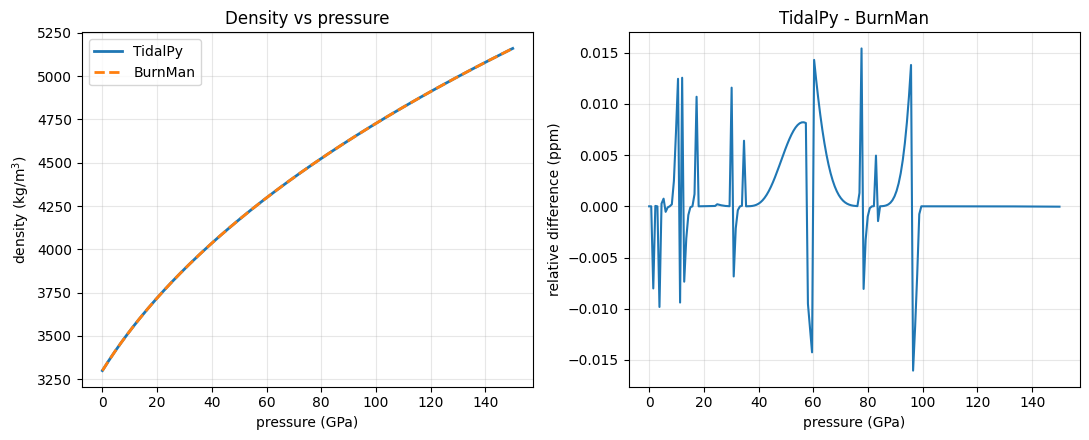

max relative difference: 1.60e-08


In [2]:
pressures = np.linspace(0.0, 150.0e9, 200)

tpy_eos = tidalpy_eos()
tpy_rho = np.array([tpy_eos.calc_density(p) for p in pressures])
bm_rho, = burnman_material().evaluate(["density"], pressures, np.full_like(pressures, 300.0))

fig, (ax, axr) = plt.subplots(1, 2, figsize=(11, 4.5))
ax.plot(pressures / 1e9, tpy_rho, label="TidalPy", lw=2)
ax.plot(pressures / 1e9, bm_rho, "--", label="BurnMan", lw=2)
ax.set_xlabel("pressure (GPa)"); ax.set_ylabel("density (kg/m$^3$)"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Density vs pressure")
axr.plot(pressures / 1e9, (tpy_rho - bm_rho) / bm_rho * 1e6)
axr.set_xlabel("pressure (GPa)"); axr.set_ylabel("relative difference (ppm)")
axr.set_title("TidalPy - BurnMan"); axr.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print(f"max relative difference: {np.max(np.abs(tpy_rho - bm_rho) / bm_rho):.2e}")


## Self-Gravitating Planet

The full integration for a single-material planet of fixed radius. BurnMan finds the self-consistent mass, which is handed to TidalPy so both codes solve the same body. The density, pressure, and gravity profiles agree.

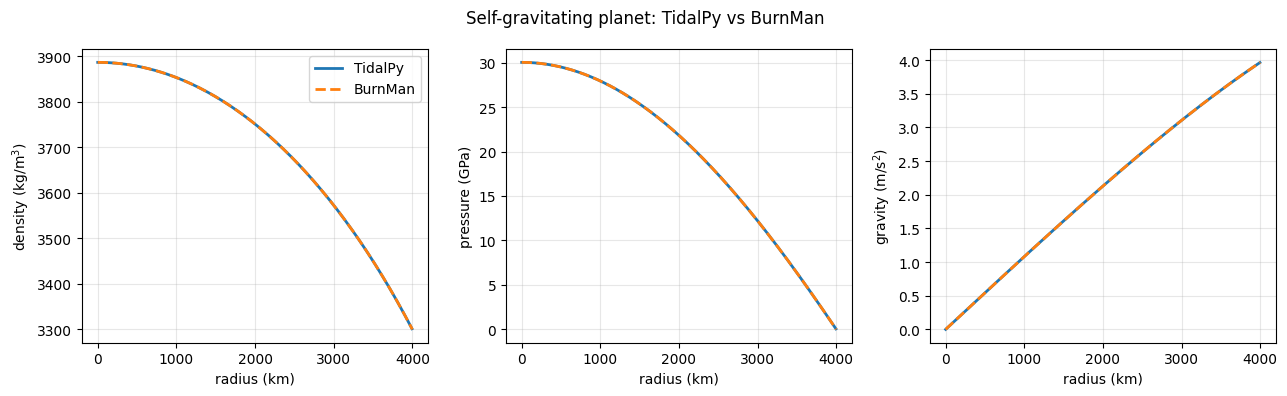

central pressure : TidalPy 30.03 GPa   BurnMan 30.03 GPa
planet mass      : TidalPy 9.5059e+23 kg   BurnMan 9.5059e+23 kg
max density diff : 9.90e-06


In [3]:
R_PLANET = 4.0e6

# BurnMan planet (self-consistent), then its mass fed to TidalPy.
bm_layer = Layer("mantle", radii=np.linspace(0.0, R_PLANET, 301))
bm_layer.set_material(burnman_material())
bm_layer.set_temperature_mode("user-defined", temperatures=np.full(301, 300.0))
bm_layer.set_pressure_mode("self-consistent", pressure_top=0.0, gravity_bottom=0.0)
bm_layer.make()
planet_mass = bm_layer.mass

world = LayeredWorld("planet", R_PLANET, planet_mass)
layer = PhysicsLayer("mantle", 0, 0.0, R_PLANET, planet_mass)
layer.set_eos(tidalpy_eos())
layer.set_shear_viscosity(make_viscosity("constant", {"reference_viscosity_pas": 1.0e21}))
layer.set_bulk_viscosity(make_viscosity("constant", {"reference_viscosity_pas": 1.0e30}))
layer.set_shear_rheology(Maxwell()); layer.set_bulk_rheology(Maxwell())
world.add_layer(layer)
world.solve_eos(G_to_use=G, temperature=300.0, verbose=False)

radii = np.linspace(1.0, 0.999 * R_PLANET, 250)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(radii / 1e3, world.get_density(radii), lw=2, label="TidalPy")
axes[0].plot(bm_layer.radii / 1e3, bm_layer.density, "--", lw=2, label="BurnMan")
axes[0].set_ylabel("density (kg/m$^3$)")
axes[1].plot(radii / 1e3, world.get_pressure(radii) / 1e9, lw=2)
axes[1].plot(bm_layer.radii / 1e3, bm_layer.pressures / 1e9, "--", lw=2)
axes[1].set_ylabel("pressure (GPa)")
axes[2].plot(radii / 1e3, world.get_gravity(radii), lw=2)
axes[2].plot(bm_layer.radii / 1e3, bm_layer.gravity, "--", lw=2)
axes[2].set_ylabel("gravity (m/s$^2$)")
for ax in axes:
    ax.set_xlabel("radius (km)"); ax.grid(alpha=0.3)
axes[0].legend()
fig.suptitle("Self-gravitating planet: TidalPy vs BurnMan")
fig.tight_layout(); plt.show()

bm_rho_on_grid = np.interp(radii, bm_layer.radii, bm_layer.density)
print(f"central pressure : TidalPy {world.central_pressure/1e9:.2f} GPa   BurnMan {bm_layer.pressures[0]/1e9:.2f} GPa")
print(f"planet mass      : TidalPy {world.planet_mass_eos:.4e} kg   BurnMan {planet_mass:.4e} kg")
print(f"max density diff : {np.max(np.abs(world.get_density(radii) - bm_rho_on_grid) / bm_rho_on_grid):.2e}")


## Performance

Timing of the full self-consistent solve for the same planet: TidalPy's compiled solver is the faster of the two.

In [4]:
def time_call(func, repeats=5):
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); func(); best = min(best, time.perf_counter() - t0)
    return best

def burnman_solve():
    lyr = Layer("m", radii=np.linspace(0.0, R_PLANET, 301))
    lyr.set_material(burnman_material())
    lyr.set_temperature_mode("user-defined", temperatures=np.full(301, 300.0))
    lyr.set_pressure_mode("self-consistent", pressure_top=0.0, gravity_bottom=0.0)
    lyr.make()

def tidalpy_solve():
    w = LayeredWorld("p", R_PLANET, planet_mass)
    la = PhysicsLayer("m", 0, 0.0, R_PLANET, planet_mass)
    la.set_eos(tidalpy_eos())
    la.set_shear_viscosity(make_viscosity("constant", {"reference_viscosity_pas": 1.0e21}))
    la.set_bulk_viscosity(make_viscosity("constant", {"reference_viscosity_pas": 1.0e30}))
    la.set_shear_rheology(Maxwell()); la.set_bulk_rheology(Maxwell())
    w.add_layer(la)
    w.solve_eos(G_to_use=G, temperature=300.0, verbose=False)

t_tpy = time_call(tidalpy_solve)
t_bm = time_call(burnman_solve)
print(f"TidalPy solve_eos : {t_tpy*1e3:7.1f} ms")
print(f"BurnMan  make     : {t_bm*1e3:7.1f} ms")
print(f"speedup           : {t_bm / t_tpy:6.1f}x")


TidalPy solve_eos :     1.2 ms
BurnMan  make     :   157.4 ms
speedup           :  132.4x


## Several Materials

The same comparison across a range of materials, varying the reference density, bulk modulus, and its pressure derivative.

In [5]:
cases = [
    ("forsterite-like", 3300.0, 130.0e9, 4.2, 0.140),
    ("MgO-like",        3585.0, 161.0e9, 3.8, 0.040),
    ("iron-like",       7870.0, 170.0e9, 5.0, 0.056),
    ("dense silicate",  4100.0, 250.0e9, 4.0, 0.100),
]

print(f"{'material':16} {'Pc_TidalPy':>11} {'Pc_BurnMan':>11} {'max rho diff':>13} {'speedup':>8}")
for name, rho0, k0, kp, mm in cases:
    bm = Mineral(params={"equation_of_state": "bm3", "V_0": mm / rho0, "K_0": k0,
                         "Kprime_0": kp, "molar_mass": mm, "P_0": 0.0, "T_0": 300.0})
    lyr = Layer("m", radii=np.linspace(0.0, R_PLANET, 301)); lyr.set_material(bm)
    lyr.set_temperature_mode("user-defined", temperatures=np.full(301, 300.0))
    lyr.set_pressure_mode("self-consistent", pressure_top=0.0, gravity_bottom=0.0)
    tb = time_call(lyr.make, repeats=3); mass = lyr.mass

    def build():
        w = LayeredWorld("p", R_PLANET, mass)
        la = PhysicsLayer("m", 0, 0.0, R_PLANET, mass)
        la.set_eos(BirchMurnaghanEOS(reference_density=rho0, reference_bulk_modulus=k0,
                                     bulk_modulus_derivative=kp,
                                     shear_modulus_static=80.0e9, bulk_modulus_static=k0))
        la.set_shear_viscosity(make_viscosity("constant", {"reference_viscosity_pas": 1.0e21}))
        la.set_bulk_viscosity(make_viscosity("constant", {"reference_viscosity_pas": 1.0e30}))
        la.set_shear_rheology(Maxwell()); la.set_bulk_rheology(Maxwell())
        w.add_layer(la); w.solve_eos(G_to_use=G, temperature=300.0, verbose=False)
        return w
    tt = time_call(build, repeats=3); w = build()
    rr = np.linspace(1.0, 0.999 * R_PLANET, 200)
    diff = np.max(np.abs(w.get_density(rr) - np.interp(rr, lyr.radii, lyr.density)) / np.interp(rr, lyr.radii, lyr.density))
    print(f"{name:16} {w.central_pressure/1e9:10.2f}G {lyr.pressures[0]/1e9:10.2f}G {diff:13.2e} {tb/tt:7.1f}x")


material          Pc_TidalPy  Pc_BurnMan  max rho diff  speedup
forsterite-like       30.03G      30.03G      9.87e-06   112.8x
MgO-like              35.27G      35.27G      6.97e-06   114.8x
iron-like            275.70G     275.68G      1.36e-04    94.8x
dense silicate        44.64G      44.64G      4.98e-06   139.2x
